In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [2]:
# Cargar el dataset
data = pd.read_csv("dataset_regresion_multiple.csv", sep=";")

# Ver las primeras filas
print(data.head())

# Descripción estadística
print(data.describe())

   edad  horas_ejercicio  peso  estres  ingresos  horas_tv  presion_arterial
0    58                7    81       1     21150        12             73.83
1    48                2    55       1     94740        22             82.26
2    34                2    81       3     86617        24             90.47
3    62                0    53       6     36896        34             93.49
4    27                4    60       7     66175        29             65.74
             edad  horas_ejercicio       peso      estres      ingresos  \
count  100.000000       100.000000  100.00000  100.000000    100.000000   
mean    41.600000         4.370000   73.28000    4.700000  59778.350000   
std     13.311346         3.013957   14.29917    2.512595  23603.253158   
min     20.000000         0.000000   50.00000    1.000000  20412.000000   
25%     30.000000         2.000000   60.00000    3.000000  38042.000000   
50%     41.500000         4.000000   73.00000    5.000000  58634.500000   
75%     53.25

                      edad  horas_ejercicio      peso    estres  ingresos  \
edad              1.000000        -0.195928 -0.000361 -0.174863 -0.114863   
horas_ejercicio  -0.195928         1.000000 -0.021882 -0.041216 -0.005404   
peso             -0.000361        -0.021882  1.000000  0.056342 -0.018638   
estres           -0.174863        -0.041216  0.056342  1.000000 -0.079145   
ingresos         -0.114863        -0.005404 -0.018638 -0.079145  1.000000   
horas_tv          0.139984         0.058045  0.012098 -0.130028 -0.034992   
presion_arterial  0.418731        -0.358865  0.588843  0.366368 -0.009394   

                  horas_tv  presion_arterial  
edad              0.139984          0.418731  
horas_ejercicio   0.058045         -0.358865  
peso              0.012098          0.588843  
estres           -0.130028          0.366368  
ingresos         -0.034992         -0.009394  
horas_tv          1.000000          0.040789  
presion_arterial  0.040789          1.000000  


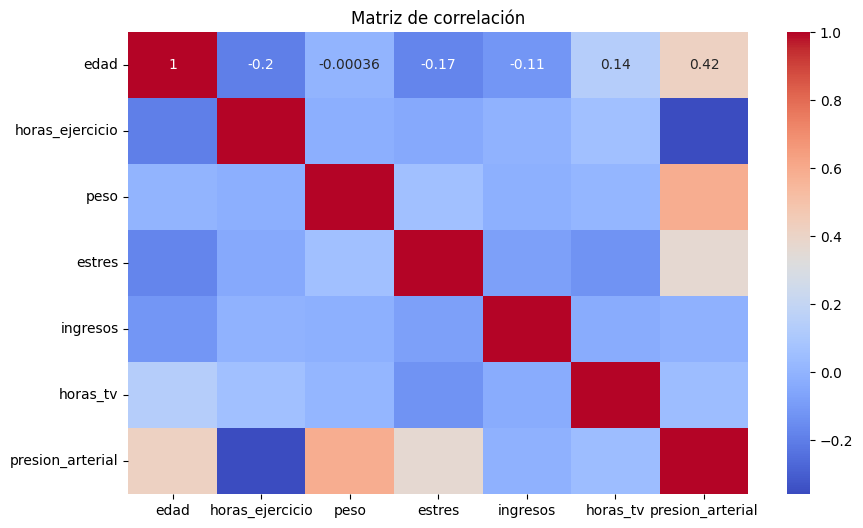

In [5]:
# Matriz de correlación
corr = data.corr()
print(corr)

# Visualización de la correlación
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

Edad (0.42) → correlación positiva moderada con la presión arterial. A mayor edad, mayor presión.

Peso (0.59) → correlación positiva fuerte, es la variable más asociada a la presión arterial.

Estrés (0.37) → correlación positiva moderada. Más estrés, más presión arterial.

Horas de ejercicio (-0.36) → correlación negativa. El ejercicio ayuda a reducir la presión arterial.

Ingresos (-0.009) → casi sin relación con la presión arterial.

Horas de TV (0.04) → correlación prácticamente nula.

Conclusión: peso, edad, estrés y ejercicio parecen las variables más influyentes.

In [7]:
# Modelo de regresión lineal múltiple
# Variables predictoras
X = data[['edad', 'horas_ejercicio', 'peso', 'estres', 'ingresos', 'horas_tv']]

# Variable objetivo
y = data['presion_arterial']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Coeficientes
coef_df = pd.DataFrame({'Variable': X.columns, 'Coeficiente': model.coef_})
print(coef_df)

          Variable  Coeficiente
0             edad     0.704516
1  horas_ejercicio    -1.606815
2             peso     0.796449
3           estres     3.566095
4         ingresos     0.000098
5         horas_tv     0.133066


In [23]:
# R²
r2 = r2_score(y_test, y_pred)

# RMSE (raíz del error cuadrático medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAE (error absoluto medio)
mae = mean_absolute_error(y_test, y_pred)

print("R²:", round(r2, 3))
print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))

R²: 0.708
RMSE: 10.36
MAE: 8.6


El modelo de regresión lineal múltiple con todas las variables explica el 70,8% de la variabilidad de la presión arterial (R²=0.708). El error medio de predicción es de aproximadamente 8–10 mmHg (RMSE=10.36 y MAE=8.60). Esto indica que el modelo tiene un buen poder explicativo, aunque presenta un margen de error moderado, lo que es razonable dado que la presión arterial depende de múltiples factores difíciles de capturar en su totalidad.

In [13]:
# 3. Modelo simplificado
# =====================
X_simple = data[["edad", "horas_ejercicio", "peso", "estres"]]

modelo_simple = LinearRegression()
modelo_simple.fit(X_simple, y)

y_pred_simple = modelo_simple.predict(X_simple)

r2_simple = r2_score(y, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y, y_pred_simple))
mae_simple = mean_absolute_error(y, y_pred_simple)

In [25]:
print("\nModelo Simplificado")
print("R²:", round(r2_simple, 3))
print("RMSE:", round(rmse_simple, 2))
print("MAE:", round(mae_simple, 2))


Modelo Simplificado
R²: 0.75
RMSE: 10.22
MAE: 8.12


El modelo simplificado alcanza un R² de 0.75, lo que significa que explica el 75% de la variabilidad en la presión arterial, mejorando el ajuste respecto al modelo completo. Además, reduce ligeramente los errores de predicción (RMSE=10.22 y MAE=8.12), lo que indica que es un modelo más eficiente y preciso al utilizar solo las variables más relevantes.

In [19]:
coef_simple = pd.DataFrame({
    "Variable": X_simple.columns,
    "Coeficiente": modelo_simple.coef_
})
print("\nCoeficientes modelo simplificado:")
print(coef_simple)


Coeficientes modelo simplificado:
          Variable  Coeficiente
0             edad     0.680988
1  horas_ejercicio    -1.658922
2             peso     0.805569
3           estres     3.284361


## Conclusión

Los resultados indican que las variables con mayor peso explicativo en la presión arterial son estrés, peso, edad y ejercicio físico.

El estrés es la variable con mayor impacto positivo.

El ejercicio actúa como factor protector, reduciendo la presión arterial.

Ingresos y horas de TV no tienen influencia significativa.

En conclusión, el modelo simplificado resulta ser más adecuado, ya que mejora ligeramente la precisión (R² más alto y errores menores) y ofrece una interpretación más clara al centrarse en los verdaderos determinantes de la presión arterial.